# Ingresar los datos en formato data frame con columnas:
- X (parámetro escalado entre 0 y 1) "X_esc"
- Y (parámetro escalado entre 0 y 1) "Y_esc"
- Kt "Kt"
- Sen(Hmax) "senHMAX"
- Transmitancia calculada con observaciones "transmitancia"
- Error heterocedástico (por observación) "error_T"
- PPFD extraterrestre (cálculo teórico)

Un data frame por tratamiento

In [ ]:
# ingresar los datos para entrenamiento del modelo

# Defino el kernel cuadrático al que se le pueden seleccionar los términos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel, Hyperparameter
from sklearn.utils.validation import check_array
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

class QuadraticSelectiveKernel(Kernel):
    """
    Kernel cuadrático con selección de términos.
    14 términos posibles:
      4 lineales
      4 cuadráticos
      6 interacciones
    """

    def __init__(self, active_terms=None, theta_bounds=(1e-5, 1e5)):
        super().__init__()

        # Si no se pasa nada → todos activos
        if active_terms is None:
            self.active_terms = np.ones(14, dtype=bool)
        else:
            self.active_terms = np.asarray(active_terms, dtype=bool)

        if self.active_terms.size != 14:
            raise ValueError("active_terms debe tener longitud 14")

        self.n_active = self.active_terms.sum()
        self.theta_bounds = theta_bounds

        # θ solo para términos activos
        self._theta_val = np.ones(self.n_active)

        self.theta_hyperparameter = Hyperparameter(
            "theta", "numeric",
            (np.log(theta_bounds[0]), np.log(theta_bounds[1])),
            self.n_active
        )

    # --- θ en log (sklearn) ---
    @property
    def theta(self):
        return np.log(self._theta_val)

    @theta.setter
    def theta(self, value):
        self._theta_val = np.exp(value)

    @property
    def bounds(self):
        return self.theta_hyperparameter.bounds

    # --- φ(X) completo ---
    def _phi_full(self, X):
        X = check_array(X)
        if X.shape[1] != 4:
            raise ValueError("Se esperaban 4 predictores")

        x1, x2, x3, x4 = X.T

        return np.column_stack([
            x1, x2, x3, x4,
            x1**2, x2**2, x3**2, x4**2,
            x1*x2, x1*x3, x1*x4,
            x2*x3, x2*x4, x3*x4
        ])

    # --- φ(X) filtrado ---
    def _phi(self, X):
        phi = self._phi_full(X)
        return phi[:, self.active_terms]

    # --- Kernel ---
    def __call__(self, X, Y=None, eval_gradient=False):
        phi_X = self._phi(X)

        if Y is None:
            phi_Y = phi_X
        else:
            phi_Y = self._phi(Y)

        K = phi_X @ np.diag(self._theta_val) @ phi_Y.T

        if eval_gradient:
            grads = []
            for i in range(self.n_active):
                grads.append(
                    self._theta_val[i] * np.outer(phi_X[:, i], phi_Y[:, i])
                )
            return K, np.stack(grads, axis=2)

        return K

    def diag(self, X):
        phi = self._phi(X)
        return np.sum(phi**2 * self._theta_val, axis=1)

    def is_stationary(self):
        return False

    def __repr__(self):
        return (
            f"QuadraticSelectiveKernel("
            f"n_active={self.n_active}, "
            f"theta={self._theta_val})"
        )

# Defino la función de ENTRENAMIENTO
Requiere un data frame de entrada:
- Con los 4 predictores en columnas en orden: X_esc, Y_esc, Kt y senHMAX
- Con una columna la transmitancia calculada a partir de observaciones
- Con una columna el error de cada observacion (ruido heterocedástico)

También requiere un vector de 14 elementos numéricos: 0 (inactivo) y 1 (activo) para determinar los términos activos en el kernel cuadrático

Cambiar los bounds según el tratamiento antes de entrenar!!!

In [21]:
def entrenar_gpr_rbf_cuadratico_selectivo(X, y, alpha, active_terms):

    bounds = [
        (1e-1, 1e1), # X
        (1e-1, 1e1), # Y
        (1e-2, 1e2), # Kt
        #(0.13 , 1e2) # senHMAX SIN MS
        (0.1, 1e2) # senHMAX CON MS
    ]

    kernel = (
        RBF(
            length_scale=np.ones(X.shape[1]),
            length_scale_bounds=bounds
        )
        +
        QuadraticSelectiveKernel(active_terms=active_terms)
        +
        WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-4, 1e2))
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=0
    )

    gpr.fit(X, y)

    return gpr, X

Entreno el modelo sin MS

In [6]:
# El orden es:
# X_esc, Y_esc, Kt, senHMAX, X_esc_cuad, Y_esc_cuad, Kt_cuad, senHMAX_cuad, X_Y, X_Kt, X_senHMAX, Y_Kt, Y_senHMAX, Kt_senHMAX
active_terms_noMS = [0, # X_esc
                1, # Y_esc
                0, # Kt
                0, # senHMAX
                1, # X_esc_cuad
                1, # Y_esc_cuad
                0, # Kt_cuad
                1, # senHMAX_cuad
                1, # X_Y
                1, # X_Kt
                0, # X_senHMAX
                1, # Y_Kt
                1, # Y_senHMAX
                0] # Kt_senHMAX

# ======================================================
# Entrenar modelo
# ======================================================
X = datos_diarios_noMS[["X_esc", "Y_esc", "Kt", "senHMAX"]].values
y = datos_diarios_noMS["transmitancia"].values
alpha = datos_diarios_noMS["error_T"].values

gpr_noMS, X_noMS = entrenar_gpr_rbf_cuadratico_selectivo(X, y, alpha, active_terms_noMS)

Predicción sin MS - solo sobre puntos obs

In [5]:
# 1. Extraemos la matriz de predictores exactamente en el orden del entrenamiento
X_pred_filas_noMS = datos_diarios_noMS[["X_esc", "Y_esc", "Kt", "senHMAX"]].values

# 2. Hacemos la predicción pidiendo también el desvío estándar (incertidumbre)
y_pred_mean_noMS, y_pred_std_noMS = gpr_noMS.predict(X_pred_filas_noMS, return_std=True)

Entreno el modelo con MS

In [22]:
# El orden es:
# X_esc, Y_esc, Kt, senHMAX, X_esc_cuad, Y_esc_cuad, Kt_cuad, senHMAX_cuad, X_Y, X_Kt, X_senHMAX, Y_Kt, Y_senHMAX, Kt_senHMAX
active_terms_MS = [0, # X_esc
                1, # Y_esc
                0, # Kt
                1, # senHMAX
                1, # X_esc_cuad
                1, # Y_esc_cuad
                0, # Kt_cuad
                1, # senHMAX_cuad
                1, # X_Y
                0, # X_Kt
                1, # X_senHMAX
                1, # Y_Kt
                0, # Y_senHMAX
                0] # Kt_senHMAX

# ======================================================
# Entrenar modelo
# ======================================================
X = datos_diarios_MS[["X_esc", "Y_esc", "Kt", "senHMAX"]].values
y = datos_diarios_MS["transmitancia"].values
alpha = datos_diarios_MS["error_T"].values

gpr_MS, X_MS = entrenar_gpr_rbf_cuadratico_selectivo(X, y, alpha, active_terms_MS)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k1__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Predicción con MS - solo sobre puntos obs

In [25]:
# 1. Extraemos la matriz de predictores exactamente en el orden del entrenamiento
X_pred_filas_MS = datos_diarios_MS[["X_esc", "Y_esc", "Kt", "senHMAX"]].values

# 2. Hacemos la predicción pidiendo también el desvío estándar (incertidumbre)
y_pred_mean_MS, y_pred_std_MS = gpr_MS.predict(X_pred_filas_MS, return_std=True)

# Predicción y graficado continuo en 9 paneles segun valores de Kt y senHMAX

Esta parte del código predice y grafica, todo junto.
Porque al ser un sombreado continuo tiene que barrer todos los X e Y de la grilla.

## Sin MS

Transmitancia efectiva sin MS


 HIPERPARÁMETROS OPTIMIZADOS (Sin MS)
-> Ruido Blanco (White Noise): 
   1.78111e-01

-> RBF Length Scales [X, Y, Kt, senHmax]: 
   [0.7564 0.3398 0.7616 0.1717]

-> Thetas Cuadráticos Selectivos (Términos Activos): 
   [4.40000e-03 8.83300e-01 8.12833e+01 2.65600e-01 0.00000e+00 1.99360e+00
 2.09731e+01 4.98107e+01]




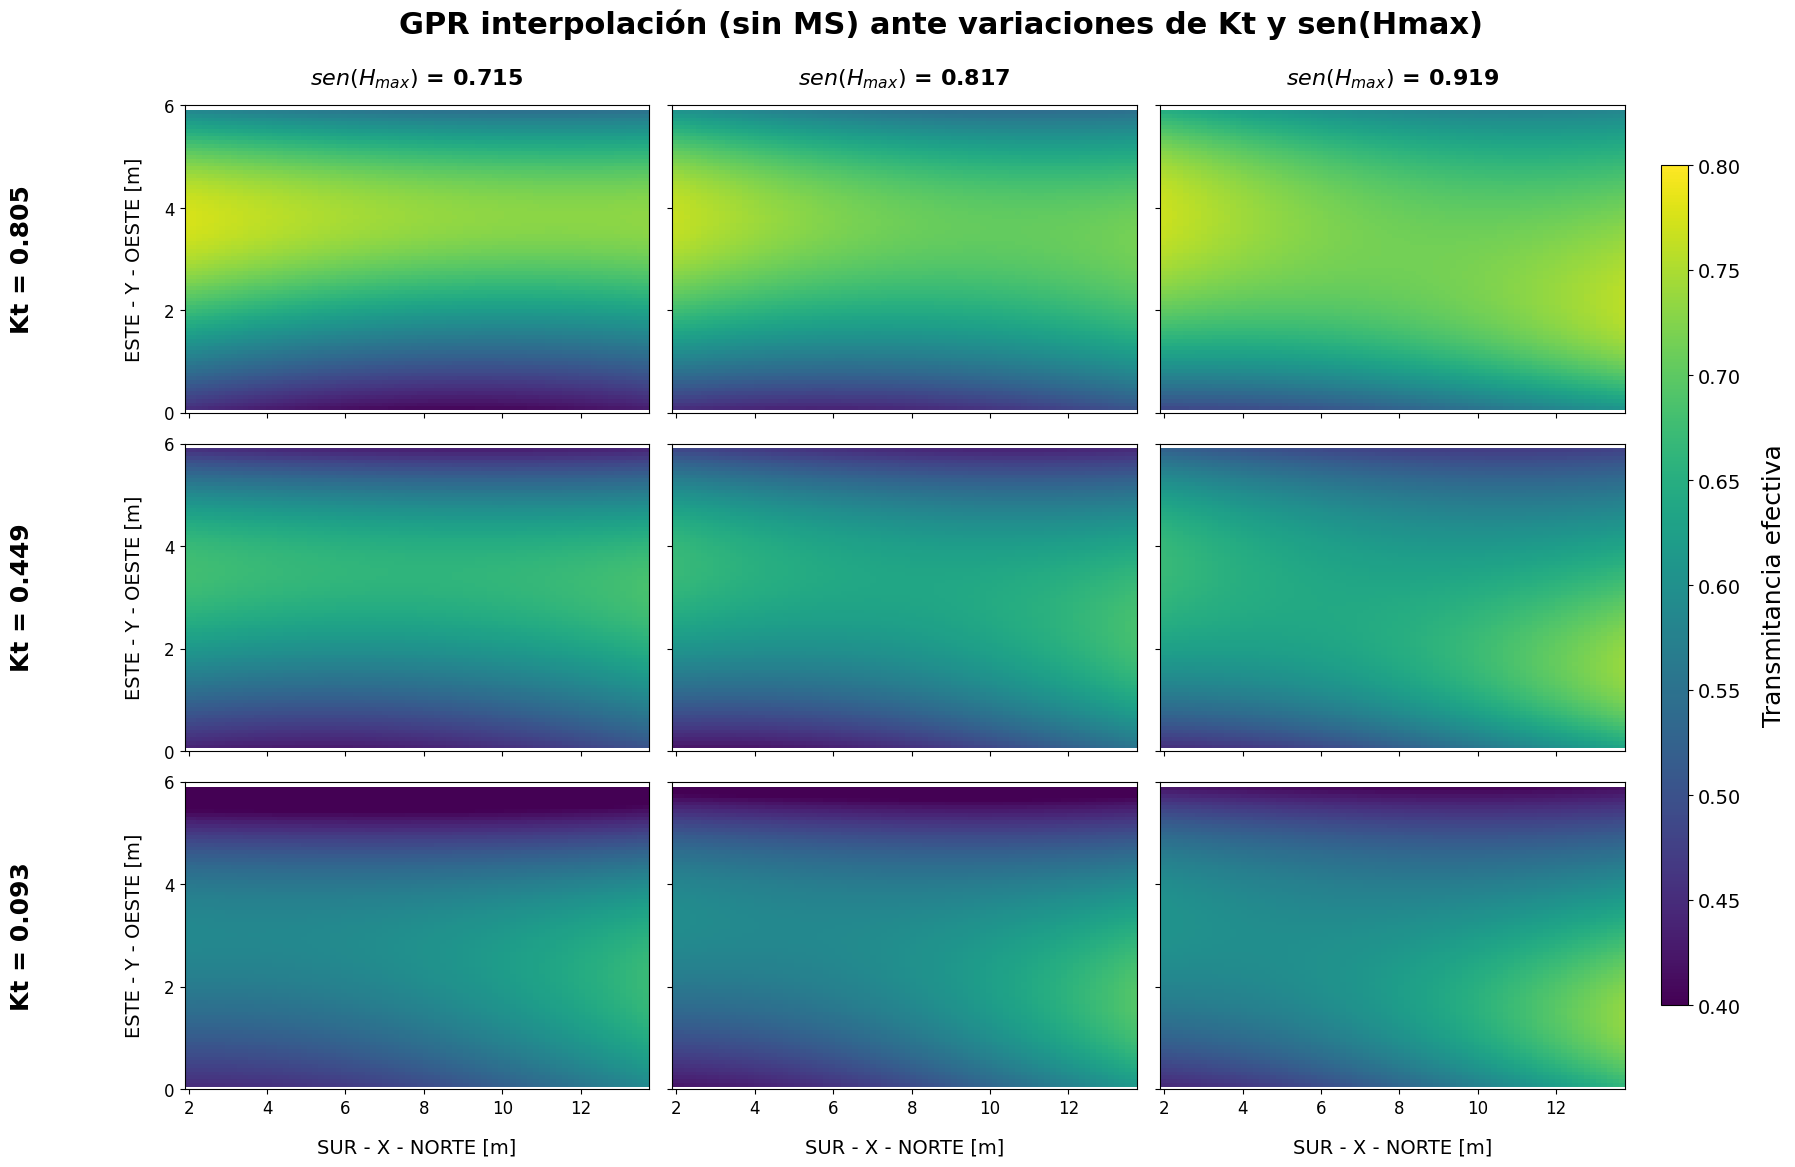

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 0. EXTRACCIÓN DE HIPERPARÁMETROS
# ==============================
print("\n" + "="*55)
print(" HIPERPARÁMETROS OPTIMIZADOS (Sin MS)")
print("="*55)

if hasattr(gpr_noMS, "kernel_"):
    # get_params() devuelve un diccionario con todos los sub-kernels
    for obj in gpr_noMS.kernel_.get_params().values():
        nombre_clase = type(obj).__name__

        if nombre_clase == 'RBF':
            print(f"-> RBF Length Scales [X, Y, Kt, senHmax]: \n   {np.round(obj.length_scale, 4)}\n")

        elif nombre_clase == 'WhiteKernel':
            print(f"-> Ruido Blanco (White Noise): \n   {obj.noise_level:.5e}\n")

        elif nombre_clase == 'QuadraticSelectiveKernel':
            print(f"-> Thetas Cuadráticos Selectivos (Términos Activos): \n   {np.round(obj._theta_val, 4)}\n")

print("="*55 + "\n")

# ==============================
# 1. VALORES DE LOS ESCENARIOS
# ==============================
# Definir los valores de Kt que se quieren plotear
Kt_vals = [
    X_noMS[:, 2].min(),
    (X_noMS[:, 2].min() + X_noMS[:, 2].max()) / 2,
    X_noMS[:, 2].max()
]

# Definir los valores de senHMAX que se quieren plotear
senH_vals = [
    X_noMS[:, 3].min(),
    (X_noMS[:, 3].min() + X_noMS[:, 3].max()) / 2,
    X_noMS[:, 3].max()
]

# Inversión para que el Kt máximo (más soleado) quede en la fila de arriba
Kt_vals_plot = Kt_vals[::-1]

# ==============================
# 2. GRILLA ESPACIAL
# ==============================
nx, ny = 80, 80
x_grid = np.linspace(X_noMS[:, 0].min(), X_noMS[:, 0].max(), nx)
y_grid = np.linspace(X_noMS[:, 1].min(), X_noMS[:, 1].max(), ny)

XX, YY = np.meshgrid(x_grid, y_grid)

# Vectores para predecir (en escala 0-1)
flat_X, flat_Y = XX.ravel(), YY.ravel()

# Matrices para graficar (en metros reales)
XX_plot = XX * 14
YY_plot = YY * 6

# Definir los limites de la barra de colores
vmin, vmax = 0.4, 0.8

# ==============================
# 3. FIGURA Y SUBPLOTS
# ==============================
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey=True)

fig.suptitle("GPR interpolación (sin MS) ante variaciones de Kt y sen(Hmax)",
             fontsize=22, fontweight='bold', y=0.98)

cmap_trans = 'viridis'

# ==============================
# 4. LOOP PRINCIPAL DE PREDICCIÓN
# ==============================
for i, Kt_val in enumerate(Kt_vals_plot):
    for j, sen_val in enumerate(senH_vals):

        # Armamos la matriz de 4 columnas para este escenario puntual
        # Aca es donde se puede EXTRAPOLAR usando datos que no son los del entrenamiento
        Xpred = np.column_stack([
            flat_X, # X "continuo" para barrer todo el campo
            flat_Y, # Y "continuo"
            np.full_like(flat_X, Kt_val), # 3 valores de Kt repetidos para cada X,Y
            np.full_like(flat_X, sen_val) # 3 valores de senHMAX repetidos para cada X,Y
        ])

        # El predict va ADENTRO del loop para generar la superficie
        y_pred, y_std = gpr_noMS.predict(Xpred, return_std=True)
        Z = y_pred.reshape(ny, nx)

        ax = axes[i, j]

        # Graficamos usando XX_plot y YY_plot (en metros)
        im = ax.pcolormesh(
            XX_plot, YY_plot, Z,
            shading="nearest",
            cmap=cmap_trans,
            vmin=vmin, vmax=vmax
        )

        # Forzamos los ticks del eje Y para que quede limpio (0, 2, 4, 6)
        ax.set_yticks([0, 2, 4, 6])

        # --- Títulos de Columnas (senHmax) ---
        if i == 0:
            ax.set_title(f"$sen(H_{{max}})$ = {sen_val:.3f}",
                         fontsize=16, fontweight='bold', pad=15)

        # --- Títulos de Filas (Kt y Eje Y) ---
        if j == 0:
            ax.set_ylabel("ESTE - Y - OESTE [m]", fontsize=14, labelpad=15)
            # Etiqueta de Kt despegada hacia la izquierda
            ax.annotate(f"Kt = {Kt_val:.3f}", xy=(-0.35, 0.5), xycoords='axes fraction',
                        ha='center', va='center', rotation=90, fontsize=18, fontweight='bold')

        # --- Títulos del Eje X ---
        if i == 2:
            ax.set_xlabel("SUR - X - NORTE [m]", fontsize=14, labelpad=15)

        ax.tick_params(axis='both', which='major', labelsize=12)

# ==============================
# 5. AJUSTES FINALES Y COLORBAR
# ==============================
fig.subplots_adjust(left=0.08, right=0.88, top=0.90, bottom=0.08, wspace=0.05, hspace=0.1)

cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Transmitancia efectiva', fontsize=18, labelpad=15)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks(np.arange(vmin, vmax + 0.01, 0.05))

plt.show()

PPFD sin MS

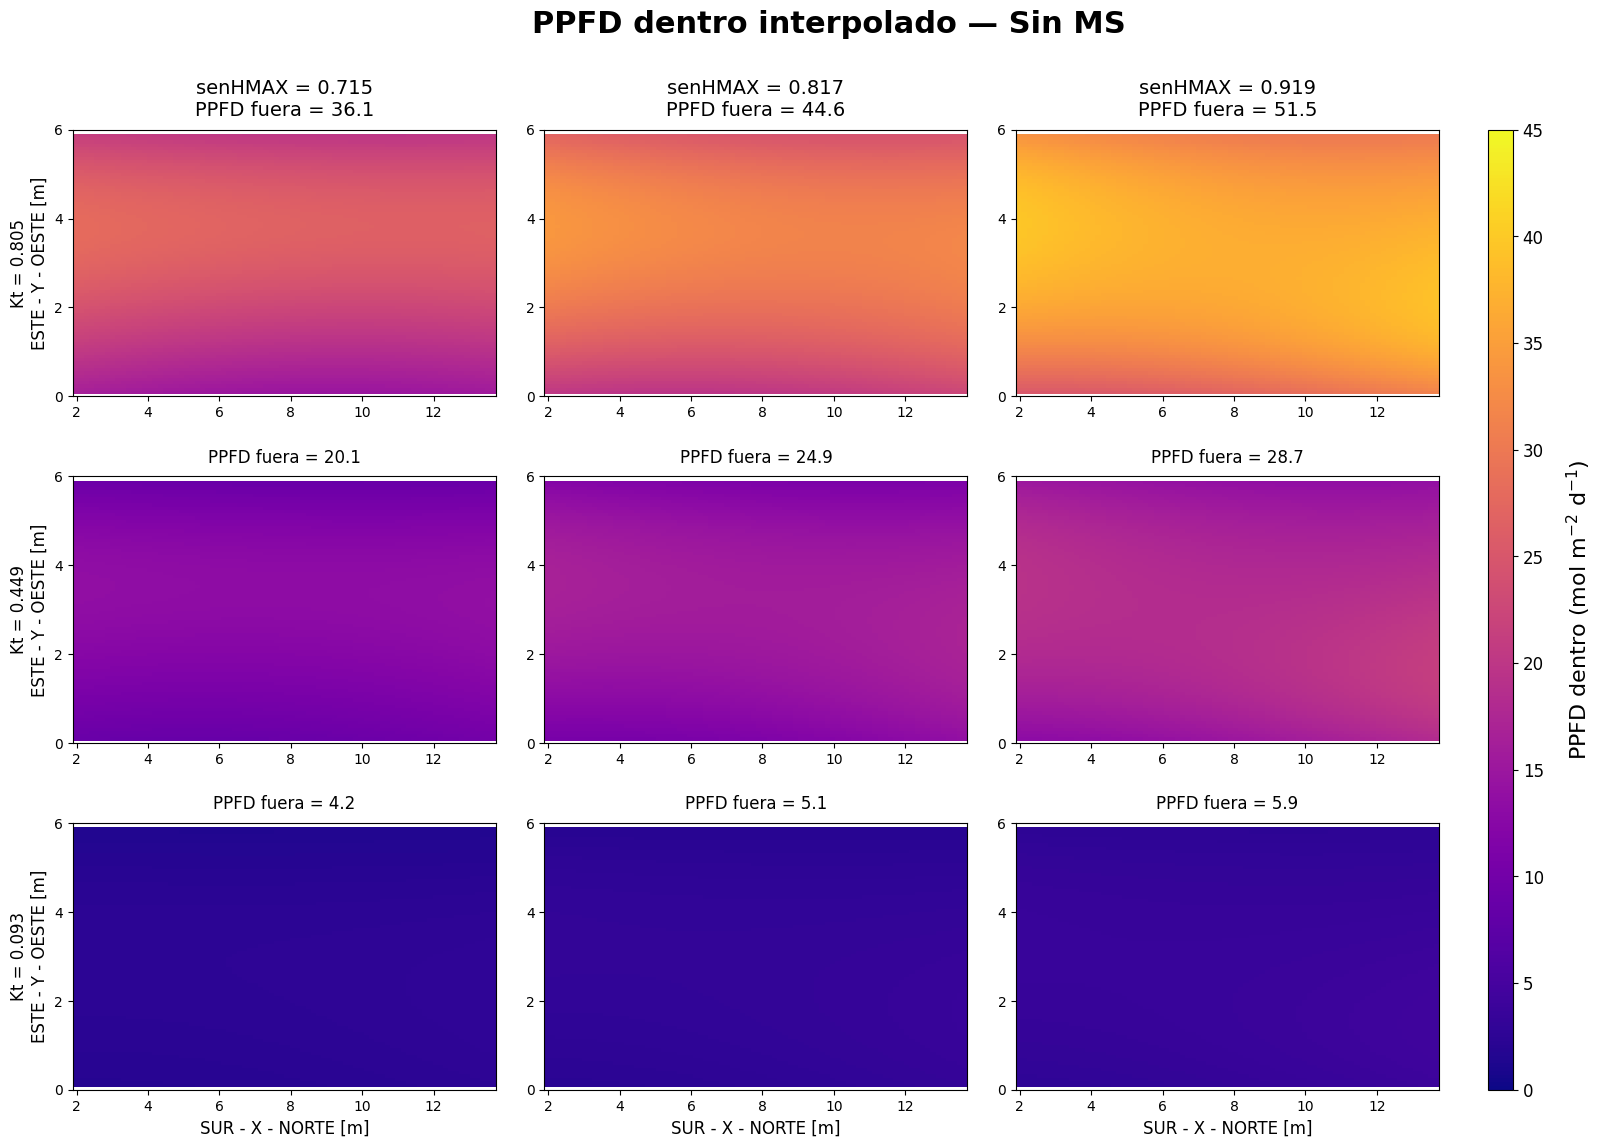

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# RANGOS Y GRILLA
# ==============================
Kt_vals = [
    X_noMS[:, 2].min(),
    (X_noMS[:, 2].min() + X_noMS[:, 2].max()) / 2,
    X_noMS[:, 2].max()
]

senH_vals = [
    X_noMS[:, 3].min(),
    (X_noMS[:, 3].min() + X_noMS[:, 3].max()) / 2,
    X_noMS[:, 3].max()
]

nx, ny = 80, 80
x_grid = np.linspace(X_noMS[:, 0].min(), X_noMS[:, 0].max(), nx)
y_grid = np.linspace(X_noMS[:, 1].min(), X_noMS[:, 1].max(), ny)
XX, YY = np.meshgrid(x_grid, y_grid)
flat_X, flat_Y = XX.ravel(), YY.ravel()

# Matrices para graficar (en metros reales)
XX_plot = XX * 14
YY_plot = YY * 6

# ==============================
# PAR LIMITES
# ==============================
vmin_par, vmax_par = 0, 45

# ==============================
# FIGURA
# ==============================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, width_ratios=[1, 1, 1, 0.06])

axes = np.empty((3, 3), dtype=object)

for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

cax = fig.add_subplot(gs[:, 3])

fig.suptitle("PPFD dentro interpolado — Sin MS", fontsize=22, fontweight='bold', y=0.98)

# ==============================
# Kt invertido
# ==============================
Kt_vals_plot = Kt_vals[::-1]

im = None

for i, Kt_val in enumerate(Kt_vals_plot):
    for j, sen_val in enumerate(senH_vals):

        # Armamos la matriz de 4 columnas para este escenario puntual
        # Aca es donde se puede EXTRAPOLAR usando datos que no son los del entrenamiento
        Xpred = np.column_stack([
            flat_X, # X "continuo" para barrer todo el campo
            flat_Y, # Y "continuo"
            np.full_like(flat_X, Kt_val), # 3 valores de Kt repetidos para cada X,Y
            np.full_like(flat_X, sen_val) # 3 valores de senHMAX repetidos para cada X,Y
        ])

        y_trans_pred = gpr_noMS.predict(Xpred)

        # 2. PAR fuera (Calculado como Kt * PAR_EXT)
        # Buscamos el PAR_EXT promedio para los días que tienen un senH similar a este panel
        mascara_cercanos = np.isclose(datos_diarios_noMS['senHMAX'], sen_val, atol=0.05)

        if mascara_cercanos.any():
            par_ext_medio = datos_diarios_noMS.loc[mascara_cercanos, 'PAR_EXT'].mean()
        else:
            par_ext_medio = datos_diarios_noMS['PAR_EXT'].mean() # Respaldo

        # Cálculo explícito de la PAR_OUT según tu regla
        par_fuera_ref = Kt_val * par_ext_medio

        # 3. PAR dentro
        Z_par = (y_trans_pred * par_fuera_ref).reshape(ny, nx)

        ax = axes[i, j]

        im = ax.pcolormesh(
            XX_plot, YY_plot, Z_par,
            shading="nearest",
            vmin=vmin_par, vmax=vmax_par,
            cmap='plasma'
        )

        # ==========================
        # EJE LIMPIO
        # ==========================
        ax.set_yticks([0, 2, 4, 6])

        if i == 2:
            ax.set_xlabel("SUR - X - NORTE [m]", fontsize=12)

        if j == 0:
            ax.set_ylabel(f"Kt = {Kt_val:.3f}\nESTE - Y - OESTE [m]", fontsize=12)

        # ==========================
        # TÍTULOS CON PAR_OUT
        # ==========================
        titulo_par = f"PPFD fuera = {par_fuera_ref:.1f}"

        if i == 0:
            # Fila superior: muestra senH y la PAR_OUT calculada
            ax.set_title(f"senHMAX = {sen_val:.3f}\n{titulo_par}", fontsize=14, pad=10)
        else:
            # Resto de las filas: solo la PAR_OUT para no saturar
            ax.set_title(f"{titulo_par}", fontsize=12, pad=10)

# ==============================
# COLORBAR ÚNICA
# ==============================
fig.subplots_adjust(left=0.08, right=0.88, top=0.88, bottom=0.08, wspace=0.15, hspace=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("PPFD dentro (mol m$^{-2}$ d$^{-1}$)", fontsize=16, labelpad=15)
cbar.ax.tick_params(labelsize=12)

plt.show()

PPFD sin MS con contornos de varianza

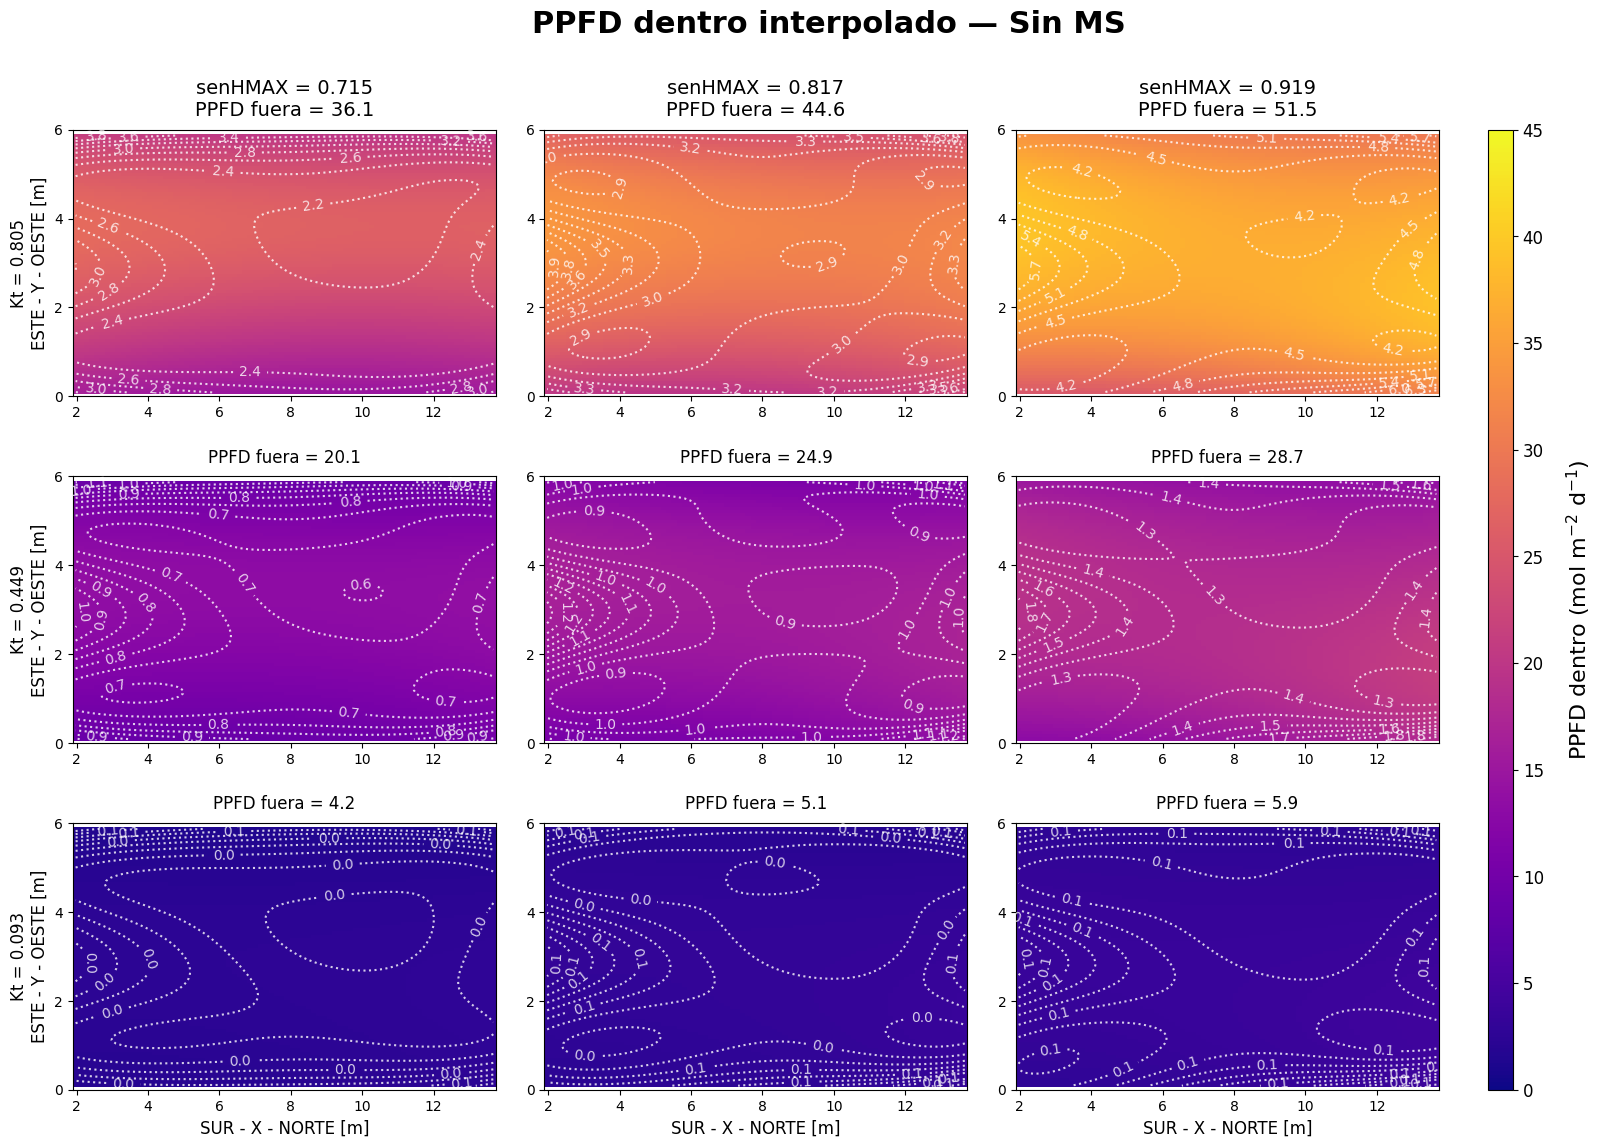

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# RANGOS Y GRILLA
# ==============================
Kt_vals = [
    X_noMS[:, 2].min(),
    (X_noMS[:, 2].min() + X_noMS[:, 2].max()) / 2,
    X_noMS[:, 2].max()
]

senH_vals = [
    X_noMS[:, 3].min(),
    (X_noMS[:, 3].min() + X_noMS[:, 3].max()) / 2,
    X_noMS[:, 3].max()
]

nx, ny = 80, 80
x_grid = np.linspace(X_noMS[:, 0].min(), X_noMS[:, 0].max(), nx)
y_grid = np.linspace(X_noMS[:, 1].min(), X_noMS[:, 1].max(), ny)
XX, YY = np.meshgrid(x_grid, y_grid)
flat_X, flat_Y = XX.ravel(), YY.ravel()

# Matrices para graficar (en metros reales)
XX_plot = XX * 14
YY_plot = YY * 6

# ==============================
# PAR LIMITES
# ==============================
vmin_par, vmax_par = 0, 45

# ==============================
# FIGURA
# ==============================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, width_ratios=[1, 1, 1, 0.06])

axes = np.empty((3, 3), dtype=object)

for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

cax = fig.add_subplot(gs[:, 3])

fig.suptitle("PPFD dentro interpolado — Sin MS", fontsize=22, fontweight='bold', y=0.98)

# ==============================
# Kt invertido
# ==============================
Kt_vals_plot = Kt_vals[::-1]

im = None

for i, Kt_val in enumerate(Kt_vals_plot):
    for j, sen_val in enumerate(senH_vals):

        # Armamos la matriz de 4 columnas para este escenario puntual
        # Aca es donde se puede EXTRAPOLAR usando datos que no son los del entrenamiento
        Xpred = np.column_stack([
            flat_X, # X "continuo" para barrer todo el campo
            flat_Y, # Y "continuo"
            np.full_like(flat_X, Kt_val), # 3 valores de Kt repetidos para cada X,Y
            np.full_like(flat_X, sen_val) # 3 valores de senHMAX repetidos para cada X,Y
        ])

        y_trans_pred, y_std = gpr_noMS.predict(Xpred, return_std=True)

        # 2. PAR fuera (Calculado como Kt * PAR_EXT)
        mascara_cercanos = np.isclose(datos_diarios_noMS['senHMAX'], sen_val, atol=0.05)

        if mascara_cercanos.any():
            par_ext_medio = datos_diarios_noMS.loc[mascara_cercanos, 'PAR_EXT'].mean()
        else:
            par_ext_medio = datos_diarios_noMS['PAR_EXT'].mean() # Respaldo

        par_fuera_ref = Kt_val * par_ext_medio

        # 3. CONVERSIÓN A PPFD (Media e Incertidumbre)
        # Multiplicamos ambas cosas por par_fuera_ref para pasarlas a unidades de PPFD
        Z_par = (y_trans_pred * par_fuera_ref).reshape(ny, nx)
        Z_std_par = (y_std * par_fuera_ref).reshape(ny, nx)

        ax = axes[i, j]

        # Mapa de calor de la PPFD
        im = ax.pcolormesh(
            XX_plot, YY_plot, Z_par,
            shading="nearest",
            vmin=vmin_par, vmax=vmax_par,
            cmap='plasma'
        )

        # 4. CONTORNOS DE INCERTIDUMBRE (Ahora en unidades de PPFD)
        contornos = ax.contour(
            XX_plot, YY_plot, Z_std_par**2,
            levels=10,
            colors='white',
            linestyles='dotted',
            alpha=0.8,
            linewidths=1.5
        )

        # Etiquetamos los contornos (le saco un decimal porque ahora es un número más grande)
        ax.clabel(contornos, inline=True, fontsize=10, fmt='%.1f', colors='white')

        # ==========================
        # EJE LIMPIO
        # ==========================
        ax.set_yticks([0, 2, 4, 6])

        if i == 2:
            ax.set_xlabel("SUR - X - NORTE [m]", fontsize=12)

        if j == 0:
            ax.set_ylabel(f"Kt = {Kt_val:.3f}\nESTE - Y - OESTE [m]", fontsize=12)

        # ==========================
        # TÍTULOS CON PAR_OUT
        # ==========================
        titulo_par = f"PPFD fuera = {par_fuera_ref:.1f}"

        if i == 0:
            ax.set_title(f"senHMAX = {sen_val:.3f}\n{titulo_par}", fontsize=14, pad=10)
        else:
            ax.set_title(f"{titulo_par}", fontsize=12, pad=10)

# ==============================
# COLORBAR ÚNICA
# ==============================
fig.subplots_adjust(left=0.08, right=0.88, top=0.88, bottom=0.08, wspace=0.15, hspace=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("PPFD dentro (mol m$^{-2}$ d$^{-1}$)", fontsize=16, labelpad=15)
cbar.ax.tick_params(labelsize=12)

plt.show()

## Con MS

Transmitancia efectiva con MS


 HIPERPARÁMETROS OPTIMIZADOS (Con MS)
-> Ruido Blanco (White Noise): 
   8.72022e-02

-> RBF Length Scales: 
   [0.2783 0.1957 1.1079 0.1   ]

-> Thetas Cuadráticos Selectivos: 
   [1.000e-05 1.000e-05 1.000e-05 1.000e-05 1.000e-05 1.000e-05 1.000e-05
 1.000e-05]




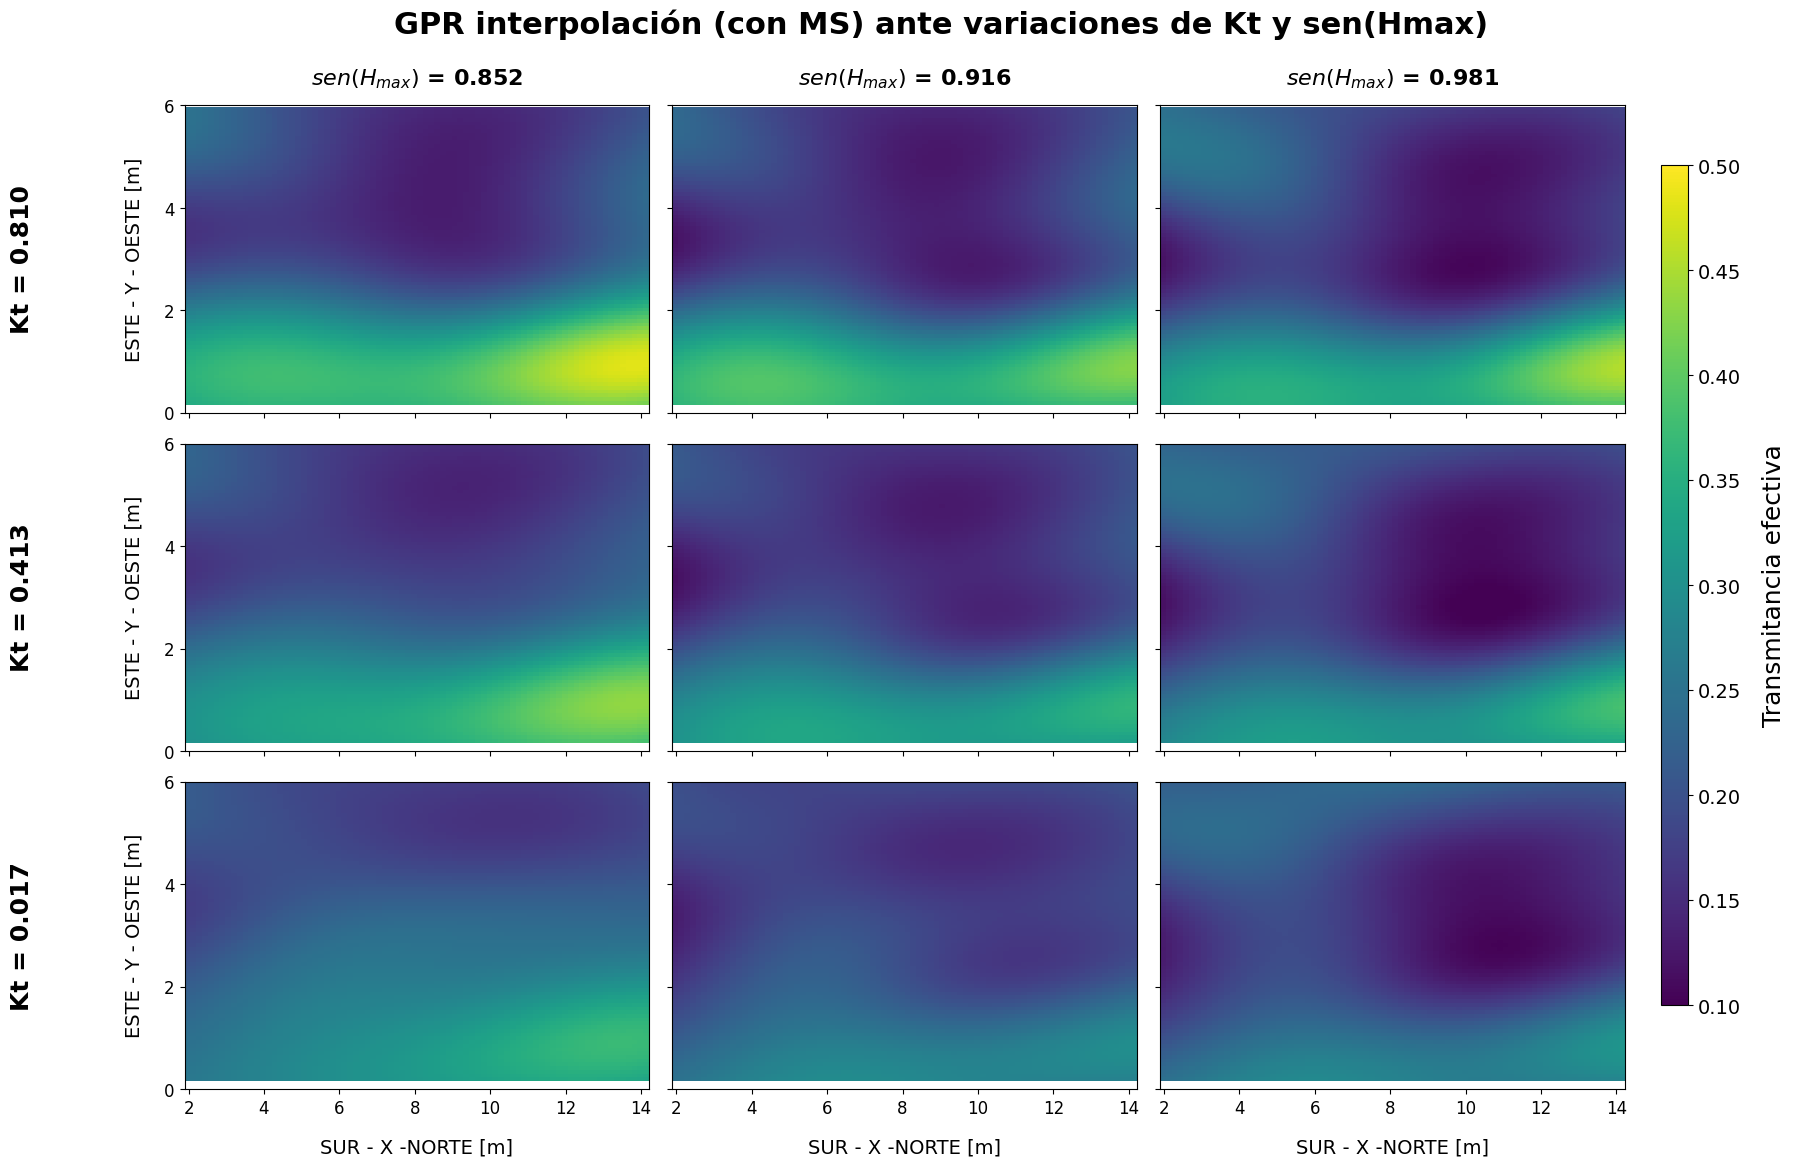

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 0. EXTRACCIÓN DE HIPERPARÁMETROS (VERSIÓN DEFINITIVA)
# ==============================
print("\n" + "="*55)
print(" HIPERPARÁMETROS OPTIMIZADOS (Con MS)")
print("="*55)

if hasattr(gpr_MS, "kernel_"):
    for obj in gpr_MS.kernel_.get_params().values():

        if hasattr(obj, 'length_scale') and not isinstance(obj, str):
            # Dejamos el RBF con 4 decimales porque sus valores suelen ser > 0.01
            print(f"-> RBF Length Scales: \n   {np.round(obj.length_scale, 4)}\n")

        elif hasattr(obj, 'noise_level') and not isinstance(obj, str):
            # Notación científica para el ruido
            print(f"-> Ruido Blanco (White Noise): \n   {obj.noise_level:.5e}\n")

        elif hasattr(obj, '_theta_val'):
            # Formateamos el array para que muestre notación científica sin redondear a cero
            thetas_str = np.array2string(obj._theta_val, formatter={'float_kind':lambda x: f"{x:.3e}"})
            print(f"-> Thetas Cuadráticos Selectivos: \n   {thetas_str}\n")

print("="*55 + "\n")

# ==============================
# 1. VALORES DE LOS ESCENARIOS
# ==============================
Kt_vals = [
    X_MS[:, 2].min(),
    (X_MS[:, 2].min() + X_MS[:, 2].max()) / 2,
    X_MS[:, 2].max()
]

senH_vals = [
    X_MS[:, 3].min(),
    (X_MS[:, 3].min() + X_MS[:, 3].max()) / 2,
    X_MS[:, 3].max()
]

# Inversión para que el Kt máximo (más soleado) quede en la fila de arriba
Kt_vals_plot = Kt_vals[::-1]

# ==============================
# 2. GRILLA ESPACIAL
# ==============================
nx, ny = 80, 80
x_grid = np.linspace(X_MS[:, 0].min(), X_MS[:, 0].max(), nx)
y_grid = np.linspace(X_MS[:, 1].min(), X_MS[:, 1].max(), ny)

XX, YY = np.meshgrid(x_grid, y_grid)

# Vectores para predecir (en escala 0-1)
flat_X, flat_Y = XX.ravel(), YY.ravel()

# Matrices para graficar (en metros reales)
XX_plot = XX * 14
YY_plot = YY * 6

vmin, vmax = 0.1, 0.5

# ==============================
# 3. FIGURA Y SUBPLOTS
# ==============================
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey=True)

fig.suptitle("GPR interpolación (con MS) ante variaciones de Kt y sen(Hmax)",
             fontsize=22, fontweight='bold', y=0.98)

cmap_trans = 'viridis'

# ==============================
# 4. LOOP PRINCIPAL DE PREDICCIÓN
# ==============================
for i, Kt_val in enumerate(Kt_vals_plot):
    for j, sen_val in enumerate(senH_vals):

        # Armamos la matriz de 4 columnas para este escenario puntual
        # Aca es donde se puede EXTRAPOLAR usando datos que no son los del entrenamiento
        Xpred = np.column_stack([
            flat_X, # X "continuo" para barrer todo el campo
            flat_Y, # Y "continuo"
            np.full_like(flat_X, Kt_val), # 3 valores de Kt repetidos para cada X,Y
            np.full_like(flat_X, sen_val) # 3 valores de senHMAX repetidos para cada X,Y
        ])

        # El predict va ADENTRO del loop para generar la superficie
        y_pred, y_std = gpr_MS.predict(Xpred, return_std=True)
        Z = y_pred.reshape(ny, nx)

        ax = axes[i, j]

        # Graficamos usando XX_plot y YY_plot (en metros)
        im = ax.pcolormesh(
            XX_plot, YY_plot, Z,
            shading="nearest",
            cmap=cmap_trans,
            vmin=vmin, vmax=vmax
        )

        # Forzamos los ticks del eje Y para que quede limpio (0, 2, 4, 6)
        ax.set_yticks([0, 2, 4, 6])

        # --- Títulos de Columnas (senHmax) ---
        if i == 0:
            ax.set_title(f"$sen(H_{{max}})$ = {sen_val:.3f}",
                         fontsize=16, fontweight='bold', pad=15)

        # --- Títulos de Filas (Kt y Eje Y) ---
        if j == 0:
            ax.set_ylabel("ESTE - Y - OESTE [m]", fontsize=14, labelpad=15)
            # Etiqueta de Kt despegada hacia la izquierda
            ax.annotate(f"Kt = {Kt_val:.3f}", xy=(-0.35, 0.5), xycoords='axes fraction',
                        ha='center', va='center', rotation=90, fontsize=18, fontweight='bold')

        # --- Títulos del Eje X ---
        if i == 2:
            ax.set_xlabel("SUR - X -NORTE [m]", fontsize=14, labelpad=15)

        ax.tick_params(axis='both', which='major', labelsize=12)

# ==============================
# 5. AJUSTES FINALES Y COLORBAR
# ==============================
fig.subplots_adjust(left=0.08, right=0.88, top=0.90, bottom=0.08, wspace=0.05, hspace=0.1)

cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Transmitancia efectiva', fontsize=18, labelpad=15)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks(np.arange(vmin, vmax + 0.01, 0.05))

plt.show()

PPFD con MS

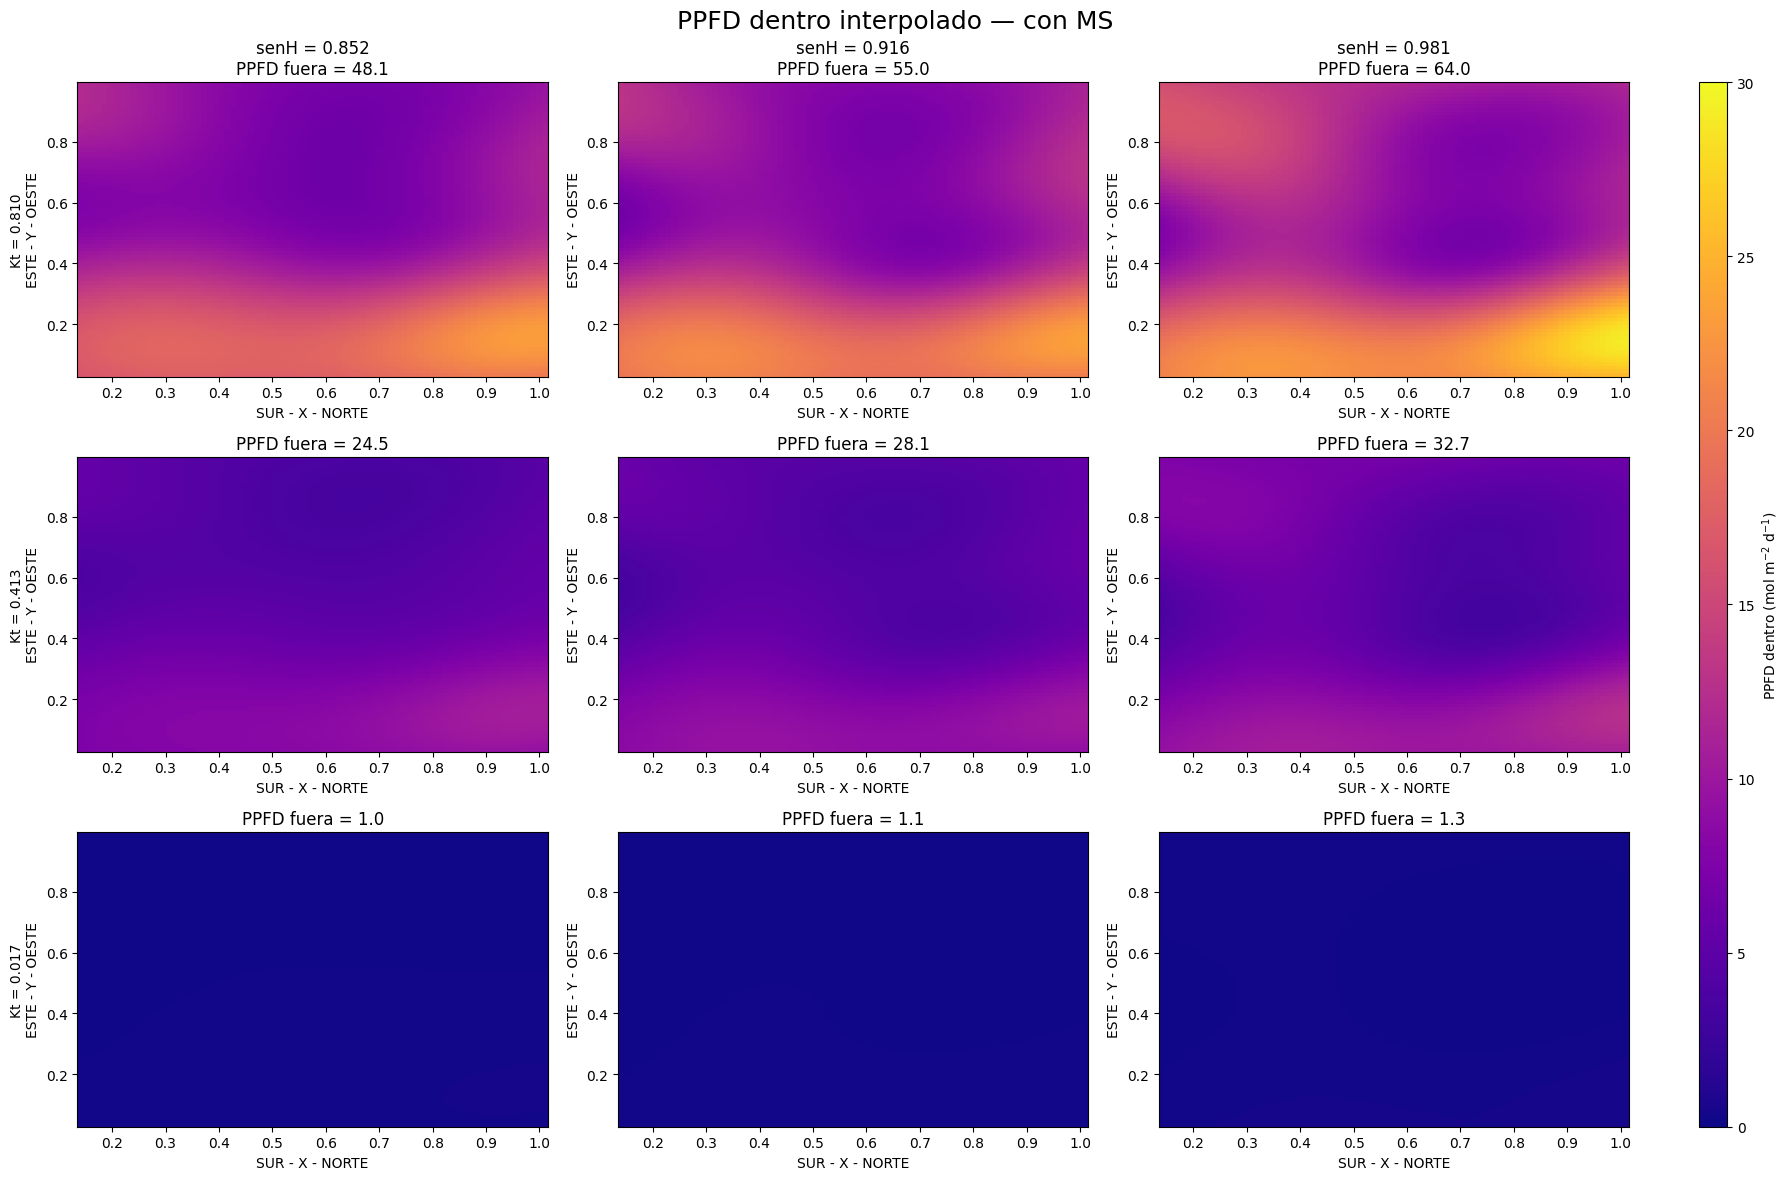

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# RANGOS Y GRILLA
# ==============================
Kt_vals = [
    X_MS[:, 2].min(),
    (X_MS[:, 2].min() + X_MS[:, 2].max()) / 2,
    X_MS[:, 2].max()
]

senH_vals = [
    X_MS[:, 3].min(),
    (X_MS[:, 3].min() + X_MS[:, 3].max()) / 2,
    X_MS[:, 3].max()
]

nx, ny = 80, 80
x_grid = np.linspace(X_MS[:, 0].min(), X_MS[:, 0].max(), nx)
y_grid = np.linspace(X_MS[:, 1].min(), X_MS[:, 1].max(), ny)
XX, YY = np.meshgrid(x_grid, y_grid)
flat_X, flat_Y = XX.ravel(), YY.ravel()

# ==============================
# PAR LIMITES
# ==============================
vmin_par, vmax_par = 0, 30

# ==============================
# FIGURA (más horizontal + colorbar externa)
# ==============================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, width_ratios=[1, 1, 1, 0.06])

axes = np.empty((3, 3), dtype=object)

for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

cax = fig.add_subplot(gs[:, 3])

fig.suptitle("PPFD dentro interpolado — con MS", fontsize=18)

# ==============================
# Kt invertido (como antes)
# ==============================
Kt_vals_plot = Kt_vals[::-1]

im = None

for i, Kt_val in enumerate(Kt_vals_plot):
    for j, sen_val in enumerate(senH_vals):

        # Armamos la matriz de 4 columnas para este escenario puntual
        # Aca es donde se puede EXTRAPOLAR usando datos que no son los del entrenamiento
        Xpred = np.column_stack([
            flat_X, # X "continuo" para barrer todo el campo
            flat_Y, # Y "continuo"
            np.full_like(flat_X, Kt_val), # 3 valores de Kt repetidos para cada X,Y
            np.full_like(flat_X, sen_val) # 3 valores de senHMAX repetidos para cada X,Y
        ])

        y_trans_pred = gpr_MS.predict(Xpred)

        # 2. PAR fuera (Calculado como Kt * PAR_EXT)
        mascara_cercanos = np.isclose(datos_diarios_MS['senHMAX'], sen_val, atol=0.005)

        if mascara_cercanos.any():
            par_ext_medio = datos_diarios_MS.loc[mascara_cercanos, 'PAR_EXT'].mean()
        else:
            par_ext_medio = datos_diarios_MS['PAR_EXT'].mean() # Respaldo

        par_fuera_ref = Kt_val * par_ext_medio

        # 3. PAR dentro
        Z_par = (y_trans_pred * par_fuera_ref).reshape(ny, nx)

        ax = axes[i, j]

        im = ax.pcolormesh(
            XX, YY, Z_par,
            shading="nearest",
            vmin=vmin_par, vmax=vmax_par,
            cmap='plasma'
        )

        # ==========================
        # EJE LIMPIO (como pediste antes)
        # ==========================
        ax.set_xlabel("SUR - X - NORTE")
        ax.set_ylabel("ESTE - Y - OESTE")

        # Kt en filas (izquierda)
        if j == 0:
            ax.set_ylabel(f"Kt = {Kt_val:.3f}\nESTE - Y - OESTE")

        # ==========================
        # TÍTULOS CON PAR_OUT (PPFD fuera)
        # ==========================
        titulo_par = f"PPFD fuera = {par_fuera_ref:.1f}"

        if i == 0:
            ax.set_title(f"senH = {sen_val:.3f}\n{titulo_par}")
        else:
            ax.set_title(f"{titulo_par}")

# ==============================
# COLORBAR ÚNICA
# ==============================
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("PPFD dentro (mol m$^{-2}$ d$^{-1}$)")

plt.tight_layout()
plt.show()

PPFD con MS y contornos de varianza

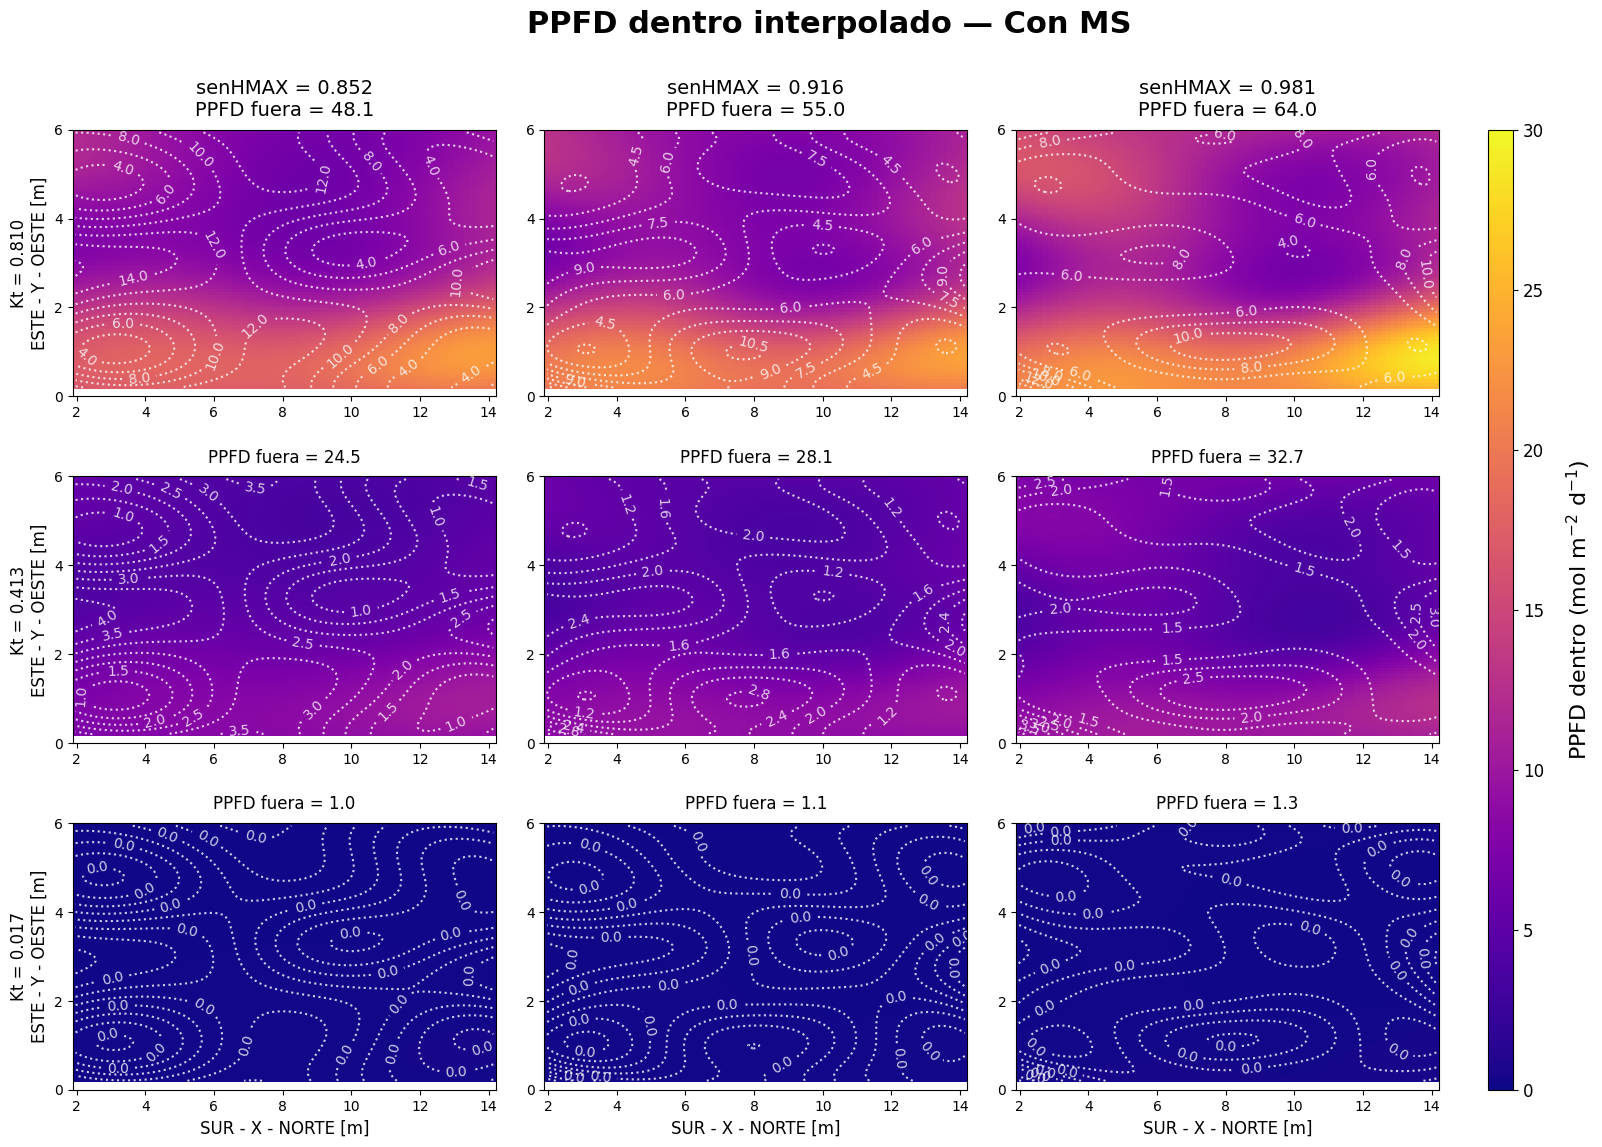

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# RANGOS Y GRILLA
# ==============================
Kt_vals = [
    X_MS[:, 2].min(),
    (X_MS[:, 2].min() + X_MS[:, 2].max()) / 2,
    X_MS[:, 2].max()
]

senH_vals = [
    X_MS[:, 3].min(),
    (X_MS[:, 3].min() + X_MS[:, 3].max()) / 2,
    X_MS[:, 3].max()
]

nx, ny = 80, 80
x_grid = np.linspace(X_MS[:, 0].min(), X_MS[:, 0].max(), nx)
y_grid = np.linspace(X_MS[:, 1].min(), X_MS[:, 1].max(), ny)
XX, YY = np.meshgrid(x_grid, y_grid)
flat_X, flat_Y = XX.ravel(), YY.ravel()

# Matrices para graficar (en metros reales)
XX_plot = XX * 14
YY_plot = YY * 6

# ==============================
# PAR LIMITES
# ==============================
vmin_par, vmax_par = 0, 30

# ==============================
# FIGURA
# ==============================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, width_ratios=[1, 1, 1, 0.06])

axes = np.empty((3, 3), dtype=object)

for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

cax = fig.add_subplot(gs[:, 3])

fig.suptitle("PPFD dentro interpolado — Con MS", fontsize=22, fontweight='bold', y=0.98)

# ==============================
# Kt invertido
# ==============================
Kt_vals_plot = Kt_vals[::-1]

im = None

for i, Kt_val in enumerate(Kt_vals_plot):
    for j, sen_val in enumerate(senH_vals):

        # Armamos la matriz de 4 columnas para este escenario puntual
        # Aca es donde se puede EXTRAPOLAR usando datos que no son los del entrenamiento
        Xpred = np.column_stack([
            flat_X, # X "continuo" para barrer todo el campo
            flat_Y, # Y "continuo"
            np.full_like(flat_X, Kt_val), # 3 valores de Kt repetidos para cada X,Y
            np.full_like(flat_X, sen_val) # 3 valores de senHMAX repetidos para cada X,Y
        ])

        y_trans_pred, y_std = gpr_MS.predict(Xpred, return_std=True)

        # 2. PAR fuera (Calculado como Kt * PAR_EXT)
        mascara_cercanos = np.isclose(datos_diarios_MS['senHMAX'], sen_val, atol=0.005)

        if mascara_cercanos.any():
            par_ext_medio = datos_diarios_MS.loc[mascara_cercanos, 'PAR_EXT'].mean()
        else:
            par_ext_medio = datos_diarios_MS['PAR_EXT'].mean() # Respaldo

        par_fuera_ref = Kt_val * par_ext_medio

        # 3. CONVERSIÓN A PPFD (Media e Incertidumbre)
        # Multiplicamos ambas cosas por par_fuera_ref para pasarlas a unidades de PPFD
        Z_par = (y_trans_pred * par_fuera_ref).reshape(ny, nx)
        Z_std_par = (y_std * par_fuera_ref).reshape(ny, nx)

        ax = axes[i, j]

        # Mapa de calor de la PPFD
        im = ax.pcolormesh(
            XX_plot, YY_plot, Z_par,
            shading="nearest",
            vmin=vmin_par, vmax=vmax_par,
            cmap='plasma'
        )

        # 4. CONTORNOS DE INCERTIDUMBRE (Ahora en unidades de varianza de PPFD)
        contornos = ax.contour(
            XX_plot, YY_plot, Z_std_par**2,
            levels=7,
            colors='white',
            linestyles='dotted',
            alpha=0.8,
            linewidths=1.5
        )

        # Etiquetamos los contornos
        ax.clabel(contornos, inline=True, fontsize=10, fmt='%.1f', colors='white')

        # ==========================
        # EJE LIMPIO
        # ==========================
        ax.set_yticks([0, 2, 4, 6])

        if i == 2:
            ax.set_xlabel("SUR - X - NORTE [m]", fontsize=12)

        if j == 0:
            ax.set_ylabel(f"Kt = {Kt_val:.3f}\nESTE - Y - OESTE [m]", fontsize=12)

        # ==========================
        # TÍTULOS CON PAR_OUT
        # ==========================
        titulo_par = f"PPFD fuera = {par_fuera_ref:.1f}"

        if i == 0:
            ax.set_title(f"senHMAX = {sen_val:.3f}\n{titulo_par}", fontsize=14, pad=10)
        else:
            ax.set_title(f"{titulo_par}", fontsize=12, pad=10)

# ==============================
# COLORBAR ÚNICA
# ==============================
fig.subplots_adjust(left=0.08, right=0.88, top=0.88, bottom=0.08, wspace=0.15, hspace=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("PPFD dentro (mol m$^{-2}$ d$^{-1}$)", fontsize=16, labelpad=15)
cbar.ax.tick_params(labelsize=12)

plt.show()